# Current datasets:

/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/Pancrm_raw.h5ad human pancreas

/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/HumanPBMC_raw.h5ad human pbmc

/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/MCA_raw.h5ad mouse cell atlas


/gpfs/gibbs/pi/zhao/tl688/tl688_data/largedataset/singlecellimmune_covid.h5ad (batch label: Site)

/gpfs/gibbs/pi/zhao/tl688/tl688_data/largedataset/core_lung_dataset.h5ad (batch label: study)

/gpfs/gibbs/pi/zhao/tl688/tl688_data/largedataset/sce_heart.h5ad (batch label: batch)


In [1]:
from __future__ import annotations

import argparse
import json
import os
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple, Any

import numpy as np

try:
    import anndata as ad
except ImportError as e:
    raise SystemExit("Please install anndata (and typically scanpy) to run this evaluator.") from e

In [2]:
def _read_h5ad(path: str) -> "ad.AnnData":
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return ad.read_h5ad(path)


def _has_all(container: Any, keys: List[str]) -> Tuple[bool, List[str]]:
    missing = [k for k in keys if k not in container]
    return (len(missing) == 0, missing)


def _is_finite_array(x: np.ndarray) -> bool:
    if x is None:
        return False
    x = np.asarray(x)
    if x.size == 0:
        return False
    return np.isfinite(x).all()


def _safe_series_values(adata: "ad.AnnData", obs_key: str) -> np.ndarray:
    if obs_key not in adata.obs:
        raise KeyError(f"obs[{obs_key}] not found")
    vals = adata.obs[obs_key].to_numpy()
    # normalize pandas categorical/object to str for stable comparisons
    return vals.astype(str)


def _align_on_obs_names(pred: "ad.AnnData", gold: "ad.AnnData") -> Tuple["ad.AnnData", "ad.AnnData"]:
    """
    Align pred and gold to shared obs_names (intersection), sorted identically.
    This avoids failing when agent filtered differently. Metrics then reflect overlap subset.
    """
    common = pred.obs_names.intersection(gold.obs_names)
    if len(common) == 0:
        raise ValueError("No overlapping cells (obs_names) between pred and gold AnnData.")
    common = common.sort_values()
    return pred[common].copy(), gold[common].copy()


def _rank_genes_groups_to_topk(adata: "ad.AnnData", group: str, k: int) -> List[str]:
    """
    Extract top-k genes for a group from adata.uns['rank_genes_groups'].

    Supports Scanpy's standard structure:
      adata.uns['rank_genes_groups']['names'] could be:
        - structured array with dtype.names == groups
        - 2D array (n_genes, n_groups) with separate 'groups' list

    We try to handle common variants.
    """
    if "rank_genes_groups" not in adata.uns:
        raise KeyError("uns['rank_genes_groups'] missing")

    rgg = adata.uns["rank_genes_groups"]
    names = rgg.get("names", None)
    if names is None:
        raise KeyError("uns['rank_genes_groups']['names'] missing")

    # Case 1: structured array (np.ndarray with dtype.names)
    if hasattr(names, "dtype") and getattr(names.dtype, "names", None):
        if group not in names.dtype.names:
            raise KeyError(f"Group '{group}' not found in rank_genes_groups names dtype.names")
        top = list(np.array(names[group])[:k].astype(str))
        return top

    # Case 2: plain 2D array with group ordering given by rgg['params']['groupby'] or rgg['names'].columns
    groups = rgg.get("names_group", None)  # rarely
    if groups is None:
        # Scanpy often stores group names in rgg['names'].dtype.names (structured) OR in rgg['params']['groups']
        groups = rgg.get("params", {}).get("groups", None)

    # Another common: rgg['names'] is a pandas DataFrame serialized? In h5ad it usually becomes ndarray.
    # Try rgg.get('groups') or rgg.get('params',{}).get('groups_order')
    if groups is None:
        groups = rgg.get("groups", None)
    if groups is None:
        groups = rgg.get("params", {}).get("groups_order", None)

    if groups is None:
        # last resort: assume columns correspond to sorted unique labels in groupby
        # but we don't have groupby here; cannot infer safely
        raise KeyError("Could not infer group ordering for rank_genes_groups['names']")

    groups = list(map(str, groups))
    if group not in groups:
        raise KeyError(f"Group '{group}' not found in rank_genes_groups groups list")
    gi = groups.index(group)

    arr = np.asarray(names)
    if arr.ndim != 2:
        raise ValueError(f"Unexpected rank_genes_groups['names'] shape: {arr.shape}")
    top = list(arr[:k, gi].astype(str))
    return top


def _overlap_at_k(pred_genes: List[str], gold_genes: List[str], k: int) -> Dict[str, float]:
    pred_top = [g for g in pred_genes[:k] if g and g != "nan"]
    gold_top = [g for g in gold_genes[:k] if g and g != "nan"]
    pred_set = set(pred_top)
    gold_set = set(gold_top)
    inter = pred_set & gold_set
    union = pred_set | gold_set
    return {
        "overlap@k": (len(inter) / float(k)) if k > 0 else 0.0,
        "jaccard@k": (len(inter) / float(len(union))) if len(union) > 0 else 0.0,
        "pred_unique": float(len(pred_set)),
        "gold_unique": float(len(gold_set)),
    }

In [3]:
@dataclass
class StepResult:
    step_id: str
    passed: bool
    checks: Dict[str, Any]
    errors: List[str]

# Task 1: read file

In [4]:
filename = "Pancrm_raw"

if filename in ["HumanPBMC_raw", "Pancrm_raw"]:
    path = f"/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/{filename}.h5ad"
else:
    path = f"/gpfs/gibbs/pi/zhao/tl688/tl688_data/largedataset/{filename}.h5ad"

import pandas as pd
if filename == 'Pancrm_raw':
    pancreas_ground = pd.read_pickle("/gpfs/gibbs/pi/zhao/wl545/agentbench/markers/pancreas_cellmarkers.pkl")
elif filename == 'HumanPBMC_raw':
    pancreas_ground = pd.read_pickle("/gpfs/gibbs/pi/zhao/wl545/agentbench/markers/pbmc_cellmarkers.pkl")
elif filename == 'sce_heart':
    pancreas_ground = pd.read_pickle("/gpfs/gibbs/pi/zhao/wl545/agentbench/markers/heart_cellmarkers.pkl")

In [5]:
##Prompt: You are an expert in bioinformatics, please write a code to read a singlecell dataset, whose path is /gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/Pancrm_raw.h5ad. If it has batch label, store it as "sample". If it has celltype label, store it as "cell_type"
##llm-generated read code (base model GPT 5.2):
import scanpy as sc

# Path to the dataset
adata_path = path

# Load the dataset
adata = sc.read_h5ad(adata_path)

print(f"Loaded AnnData: {adata}")
print("Available obs columns:", list(adata.obs.columns))

# -----------------------------
# Standardize batch label
# -----------------------------
batch_candidates = [
    "batch",
    "sample",
    "donor",
    "orig.ident",
    "library",
    "batch_id",
]

if "sample" not in adata.obs.columns:
    for col in batch_candidates:
        if col in adata.obs.columns:
            adata.obs["sample"] = adata.obs[col].astype(str)
            print(f"Batch label found: '{col}' → stored as 'sample'")
            break
    else:
        print("No batch label found.")

# -----------------------------
# Standardize cell type label
# -----------------------------
celltype_candidates = [
    "cell_type",
    "celltype",
    "celltypes",
    "cell_ontology_class",
    "annotation",
    "annot",
    "cell_label",
]

if "cell_type" not in adata.obs.columns:
    for col in celltype_candidates:
        if col in adata.obs.columns:
            adata.obs["cell_type"] = adata.obs[col].astype(str)
            print(f"Cell type label found: '{col}' → stored as 'cell_type'")
            break
    else:
        print("No cell type label found.")

# -----------------------------
# Final sanity check
# -----------------------------
print("\nFinal standardized fields:")
print("sample    :", "sample" in adata.obs.columns)
print("cell_type :", "cell_type" in adata.obs.columns)

Loaded AnnData: AnnData object with n_obs × n_vars = 738782 × 19820
    obs: 'batch', 'dataset', 'donor', 'region', 'cell_type'
    layers: 'logcounts'
Available obs columns: ['batch', 'dataset', 'donor', 'region', 'cell_type']
Batch label found: 'batch' → stored as 'sample'

Final standardized fields:
sample    : True
cell_type : True


In [6]:
if 'largedataset' in path:
    sc.pp.subsample(adata, fraction=0.1,random_state=2024)

In [7]:
# ##reference code:
# import scanpy as sc
# adata = sc.read_h5ad("../scgpt_dataset/Pancrm_raw.h5ad")
# adata.obs['sample'] = adata.obs['batch'].copy()
# adata.obs['cell_type'] = adata.obs['celltype'].copy()

In [8]:
def check_step1_load_merge(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    # Required: obs['sample'] exists with >=2 categories
    if "sample" not in adata.obs:
        errors.append("Missing obs['sample']")
    elif "cell_type" not in adata.obs:
        errors.append("Missing obs['cell type']")
    else:
        n_cat = adata.obs["sample"].nunique(dropna=False)
        checks["sample_nunique"] = int(n_cat)
        if n_cat < 2:
            errors.append(f"obs['sample'] has {n_cat} unique values; expected >=2")

    # Basic shape sanity
    checks["n_obs"] = int(adata.n_obs)
    checks["n_vars"] = int(adata.n_vars)
    if adata.n_obs <= 0 or adata.n_vars <= 0:
        errors.append("AnnData has non-positive n_obs or n_vars")

    return StepResult("step1_load_merge", len(errors) == 0, checks, errors)

In [9]:
out1 = check_step1_load_merge(adata)
print(out1.passed)

True


# Task 2: qc

In [10]:
#prompt: Generate concise, executable Python (Scanpy) code that annotates gene categories and computes QC metrics for an AnnData object called adata. Mark mitochondrial genes ("MT-" for human, "Mt-" for mouse). Mark ribosomal genes (prefix "RPS" or "RPL"). Mark hemoglobin genes (regex ^HB, excluding pseudogenes like HBP). Store each as boolean columns in adata.var. Call scanpy.pp.calculate_qc_metrics with qc_vars=["mt","ribo","hb"], log1p=True, inplace=True. Output only the code, with brief comments.
import re
import numpy as np
import scanpy as sc

# --- gene category flags in adata.var (robust to case / species conventions) ---
gn = adata.var_names.astype(str)

# Mitochondrial: human "MT-", mouse "Mt-"
adata.var["mt"] = np.fromiter((g.startswith("MT-") or g.startswith("Mt-") for g in gn), dtype=bool, count=len(gn))

# Ribosomal: "RPS" or "RPL"
adata.var["ribo"] = np.fromiter((g.startswith("RPS") or g.startswith("RPL") for g in gn), dtype=bool, count=len(gn))

# Hemoglobin: regex ^HB, excluding pseudogenes like HBP*
hb_re = re.compile(r"^HB(?!P)", flags=re.IGNORECASE)
adata.var["hb"] = np.fromiter((hb_re.match(g) is not None for g in gn), dtype=bool, count=len(gn))

# --- QC metrics ---
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], log1p=True, inplace=True)


In [11]:
# ##reference code:
# # mitochondrial genes, "MT-" for human, "Mt-" for mouse
# adata.var["mt"] = adata.var_names.str.startswith("MT-")
# # ribosomal genes
# adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# # hemoglobin genes
# adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
# sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

In [12]:
def check_step2_qc_metrics(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    # var flags
    ok, missing = _has_all(adata.var, ["mt", "ribo", "hb"])
    checks["var_flags_present"] = ok
    if not ok:
        errors.append(f"Missing var flags: {missing}")

    required_obs = [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "log1p_total_counts",
        "log1p_n_genes_by_counts",
    ]
    ok, missing = _has_all(adata.obs, required_obs)
    checks["qc_obs_keys_present"] = ok
    if not ok:
        errors.append(f"Missing qc obs keys: {missing}")

    # sanity
    if "pct_counts_mt" in adata.obs:
        pct = adata.obs["pct_counts_mt"].to_numpy()
        checks["pct_counts_mt_min"] = float(np.nanmin(pct))
        checks["pct_counts_mt_max"] = float(np.nanmax(pct))
        if np.nanmin(pct) < -1e-6 or np.nanmax(pct) > 100 + 1e-6:
            errors.append("pct_counts_mt out of expected range [0,100]")

    return StepResult("step2_qc_metrics", len(errors) == 0, checks, errors)

In [13]:
out2 = check_step2_qc_metrics(adata)

# Task 3: filter

In [14]:
# '''Generate concise, executable Python code using Scanpy to perform basic single-cell RNA-seq filtering on an AnnData object named adata.
# The code should:
# •	Filter cells with fewer than 100 detected genes
# •	Filter genes expressed in fewer than 3 cells
# Output only the code, with no explanations.
# '''
'''
Generate concise, executable Python code using Scanpy to perform basic single-cell RNA-seq filtering on an AnnData object named adata for both cells and genes.
'''
import scanpy as sc

# --- Basic QC metrics ---
# Make mitochondrial gene flag (common human "MT-" / mouse "mt-")
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

# --- Cell filtering thresholds (edit as needed) ---
MIN_GENES_PER_CELL = 200
MAX_GENES_PER_CELL = 6000
MAX_PCT_MT = 20.0

# Keep cells with enough genes, not too many genes, and low MT%
adata = adata[
    (adata.obs["n_genes_by_counts"] >= MIN_GENES_PER_CELL)
    & (adata.obs["n_genes_by_counts"] <= MAX_GENES_PER_CELL)
    & (adata.obs["pct_counts_mt"] <= MAX_PCT_MT)
].copy()

# --- Gene filtering thresholds ---
MIN_CELLS_PER_GENE = 3
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

# (Optional) remove cells with very low total counts
# MIN_COUNTS_PER_CELL = 500
# sc.pp.filter_cells(adata, min_counts=MIN_COUNTS_PER_CELL)

print(adata)


AnnData object with n_obs × n_vars = 70781 × 19191
    obs: 'batch', 'dataset', 'donor', 'region', 'cell_type', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'logcounts'


In [15]:
# ##reference code:
# sc.pp.filter_cells(adata, min_genes=100)
# sc.pp.filter_genes(adata, min_cells=3)

In [16]:
def check_step3_filter(adata: "ad.AnnData", prev: Optional["ad.AnnData"] = None) -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    checks["n_obs"] = int(adata.n_obs)
    checks["n_vars"] = int(adata.n_vars)

    if prev is not None:
        checks["prev_n_obs"] = int(prev.n_obs)
        checks["prev_n_vars"] = int(prev.n_vars)
        if adata.n_obs > prev.n_obs:
            errors.append("n_obs increased after filtering (unexpected)")
        if adata.n_vars > prev.n_vars:
            errors.append("n_vars increased after filtering (unexpected)")

    return StepResult("step3_filter", len(errors) == 0, checks, errors)

In [17]:
out3 = check_step3_filter(adata)

# Task 4: scrublet test

In [18]:
'''
Write concise, executable Python code using Scanpy to run doublet detection with Scrublet on an AnnData object named adata.
'''
try:
    import numpy as np
    import scanpy as sc
    import scrublet as scr

    # Use raw counts for Scrublet
    X = adata.X
    if sc.sparse.issparse(X):
        counts = X.tocsr()
    else:
        counts = np.asarray(X)

    # Run Scrublet
    scrub = scr.Scrublet(counts, expected_doublet_rate=0.06)
    doublet_scores, predicted_doublets = scrub.scrub_doublets()

    # Store results in AnnData
    adata.obs["doublet_score"] = doublet_scores
    adata.obs["predicted_doublet"] = predicted_doublets.astype(bool)

    # (Optional) Visualize score distribution
    # scrub.plot_histogram()
except:
    pass

In [19]:
# ##reference code:
# import scanpy as sc
# sc.pp.scrublet(adata, batch_key="sample")

In [20]:
def check_step4_scrublet(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    ok, missing = _has_all(adata.obs, ["predicted_doublet", "doublet_score"])
    checks["scrublet_keys_present"] = ok
    if not ok:
        errors.append(f"Missing scrublet keys: {missing}")

    if "doublet_score" in adata.obs:
        ds = adata.obs["doublet_score"].to_numpy()
        checks["doublet_score_finite"] = bool(np.isfinite(ds).all())
        if not np.isfinite(ds).all():
            errors.append("doublet_score contains non-finite values")

    return StepResult("step4_scrublet", len(errors) == 0, checks, errors)

In [21]:
out4 = check_step4_scrublet(adata)
print(out4)

StepResult(step_id='step4_scrublet', passed=False, checks={'scrublet_keys_present': False}, errors=["Missing scrublet keys: ['predicted_doublet', 'doublet_score']"])


# Task 5: normalization

In [22]:
'''
You are an expert in single-cell RNA-seq analysis using Python and Scanpy.
Please write Python code that preprocesses an AnnData object adata by:
1.	Saving the raw count matrix into adata.layers["counts"] 
2.	Normalizing total counts per cell to the median library size.
3.	Applying transformation to the normalized data.
'''
import numpy as np
import scanpy as sc

# 1. Save raw counts
adata.layers["counts"] = adata.X.copy()

# 2. Normalize total counts per cell to the median library size
libsize = np.array(adata.layers["counts"].sum(axis=1)).flatten()
target_sum = np.median(libsize)
sc.pp.normalize_total(adata, target_sum=target_sum)

# 3. Apply transformation (log1p is standard)
sc.pp.log1p(adata)


In [23]:
# ##reference code:
# # Saving count data
# adata.layers["counts"] = adata.X.copy()
# # Normalizing to median total counts
# sc.pp.normalize_total(adata)
# # Logarithmize the data
# sc.pp.log1p(adata)

In [24]:
def check_step5_normalize_log1p(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    # raw preservation policy: accept either adata.raw OR layers['counts']
    raw_ok = adata.raw is not None
    layers_ok = "counts" in adata.layers

    checks["raw_present"] = bool(raw_ok)
    checks["layers_counts_present"] = bool(layers_ok)

    if not (raw_ok or layers_ok):
        errors.append("Raw counts not preserved: expected adata.raw or layers['counts']")

    # log1p sanity: values should be non-negative and finite (common)
    # Note: sparse matrices handled via .X.data
    X = adata.X
    try:
        if hasattr(X, "data"):
            data = X.data
        else:
            data = np.asarray(X).ravel()
        checks["X_finite"] = bool(np.isfinite(data).all())
        if not np.isfinite(data).all():
            errors.append(".X contains non-finite values")
        # after log1p of normalized counts, should typically be >= 0 (allow tiny negative numerical)
        mn = float(np.min(data)) if data.size else 0.0
        checks["X_min"] = mn
        if mn < -1e-6:
            errors.append(f".X min is negative ({mn}); unexpected after log1p")
    except Exception as e:
        errors.append(f"Could not inspect .X: {e}")

    return StepResult("step5_normalize_log1p", len(errors) == 0, checks, errors)

In [25]:
out5 = check_step5_normalize_log1p(adata)

# Task 6: hvg and pca

In [26]:
'''
Please write concise, executable Python code that takes an existing AnnData object adata with batch information stored in sample and:
1.	Identifies highly variable genes using sc.pp.highly_variable_genes
2.	Runs PCA on the filtered features.
'''
try:
    import scanpy as sc

    # 1) Highly variable genes (batch key is in adata.obs["sample"])
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=2000,
        flavor="seurat_v3",
        batch_key="sample",
        subset=False,
    )

    # 2) PCA on HVGs (don’t permanently subset adata)
    adata_hvg = adata[:, adata.var["highly_variable"]].copy()
    sc.tl.pca(adata_hvg, svd_solver="arpack")

    # Store results back (fix: no parentheses on dict; also keep varm if desired)
    adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
    adata.uns["pca"] = adata_hvg.uns["pca"]
    adata.varm["PCs"] = adata_hvg.varm["PCs"]
except:
    pass

/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [27]:
# ##reference code:
# sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
# sc.tl.pca(adata)

In [28]:
def check_step6_hvg_pca(adata: "ad.AnnData", hvg_range: Tuple[int, int] = (1,30000)) -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    if "highly_variable" not in adata.var:
        errors.append("Missing var['highly_variable']")
        checks["hvg_count"] = None
    else:
        hvg = adata.var["highly_variable"].to_numpy()
        hvg_count = int(np.sum(hvg.astype(bool)))
        checks["hvg_count"] = hvg_count
        lo, hi = hvg_range
        if not (lo <= hvg_count <= hi):
            errors.append(f"HVG count {hvg_count} outside expected range [{lo},{hi}]")
    
    if "highly_variable_nbatches" not in adata.var:
        errors.append("Missing var['highly_variable_nbatches']")
    
    if "X_pca" not in adata.obsm:
        errors.append("Missing obsm['X_pca']")
    else:
        Xp = np.asarray(adata.obsm["X_pca"])
        checks["X_pca_shape"] = list(Xp.shape)
        if Xp.ndim != 2 or Xp.shape[0] != adata.n_obs:
            errors.append("X_pca has wrong shape")
        if not _is_finite_array(Xp):
            errors.append("X_pca has non-finite values")

    return StepResult("step6_hvg_pca", len(errors) == 0, checks, errors)

In [29]:
out6 = check_step6_hvg_pca(adata)

# Task 7: neighbor+umap

In [30]:
'''
Please write Python code that performs neighborhood graph construction and downstream visualization on an AnnData object adata by:
1.	Computing the k-nearest neighbor graph.
2.	Running Leiden clustering.
3.	Computing a UMAP embedding.
'''
import scanpy as sc

# 1) kNN graph (uses adata.obsm["X_pca"] if present; otherwise falls back appropriately)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

# 2) Leiden clustering
sc.tl.leiden(adata, key_added="leiden", flavor="igraph", n_iterations=2)

# 3) UMAP embedding
sc.tl.umap(adata)

In [31]:

# ##reference code:
# sc.pp.neighbors(adata)
# sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
# sc.tl.umap(adata)

In [32]:
def check_step7_neighbors_umap(adata: "ad.AnnData") -> StepResult:
    errors = []
    checks: Dict[str, Any] = {}

    if "connectivities" not in adata.obsp:
        errors.append("Missing obsp['connectivities']")
    else:
        checks["connectivities_shape"] = list(np.asarray(adata.obsp["connectivities"]).shape)

    if "X_umap" not in adata.obsm:
        errors.append("Missing obsm['X_umap']")
    else:
        Xu = np.asarray(adata.obsm["X_umap"])
        checks["X_umap_shape"] = list(Xu.shape)
        if Xu.shape != (adata.n_obs, 2):
            errors.append("X_umap has wrong shape; expected (n_obs, 2)")
        if not _is_finite_array(Xu):
            errors.append("X_umap has non-finite values")
        # ensure not all identical
        checks["X_umap_var_sum"] = float(np.var(Xu, axis=0).sum())
        if float(np.var(Xu, axis=0).sum()) <= 0.0:
            errors.append("X_umap appears constant")

    return StepResult("step7_neighbors_umap", len(errors) == 0, checks, errors)

In [33]:
out7 = check_step7_neighbors_umap(adata)

# Task 8: bec

In [34]:
'''
Write a code to run the best batch effect correction method for one anndata object (adata) whose batch labels are stored in "sample" key.
'''
# Best-practice “auto” batch correction for an AnnData (adata) with batch labels in adata.obs["sample"]
# - Tries Harmony (fast + robust) first; falls back to Scanorama; optionally supports scVI if installed.
# - Produces:
#   adata.obsm["X_pca_harmony"] or adata.obsm["X_scanorama"] / ["X_scvi"]
#   adata.obsm["X_umap_corrected"]
#   adata.obs["leiden_corrected"]
#
# Usage:
#   adata = run_best_batch_correction(adata, batch_key="sample", method="auto")

from __future__ import annotations
from typing import Literal, Optional
import numpy as np
import scanpy as sc

def _ensure_preprocess(
    adata,
    batch_key: str,
    n_hvg: int = 3000,
    n_pcs: int = 50,
    layer: Optional[str] = None,
):
    if batch_key not in adata.obs.columns:
        raise KeyError(f'Batch key "{batch_key}" not found in adata.obs.')

    # Use layer if specified (e.g., "counts"); otherwise use adata.X
    if layer is not None:
        if layer not in adata.layers:
            raise KeyError(f'Layer "{layer}" not found in adata.layers.')
        X_backup = adata.X
        adata.X = adata.layers[layer].copy()

    # Basic pipeline
    if "total_counts" not in adata.obs.columns:
        sc.pp.calculate_qc_metrics(adata, inplace=True)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # HVGs per batch (good default for integration)
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_hvg,
        batch_key=batch_key,
        subset=True,
        flavor="seurat_v3",
    )

    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")

    if layer is not None:
        adata.X = X_backup  # restore

def _run_harmony(adata, batch_key: str, n_pcs: int = 50):
    # Requires: pip install harmonypy scanpy
    try:
        import scanpy.external as sce
    except Exception as e:
        raise RuntimeError("scanpy.external not available. Update scanpy or install scanpy[external].") from e

    if "X_pca" not in adata.obsm:
        raise RuntimeError("PCA not found at adata.obsm['X_pca']. Run preprocessing first.")
    sce.pp.harmony_integrate(adata, key=batch_key, basis="X_pca", adjusted_basis="X_pca_harmony")
    return "X_pca_harmony"

def _run_scanorama(adata, batch_key: str, n_pcs: int = 50):
    # Requires: pip install scanorama
    try:
        import scanpy.external as sce
    except Exception as e:
        raise RuntimeError("scanpy.external not available. Update scanpy or install scanpy[external].") from e

    # split by batch
    adatas = []
    for b in adata.obs[batch_key].astype("category").cat.categories:
        adatas.append(adata[adata.obs[batch_key] == b].copy())

    # integrate on HVGs already subsetted
    sce.pp.scanorama_integrate(adatas, dimred=n_pcs)

    # merge back
    adata_int = adatas[0].concatenate(*adatas[1:], batch_key="__tmp_batch__", index_unique=None)
    # scanorama stores corrected low-dim in .obsm["X_scanorama"]
    adata.obsm["X_scanorama"] = adata_int.obsm["X_scanorama"].copy()
    return "X_scanorama"

def _run_scvi(adata, batch_key: str, n_latent: int = 30):
    # Requires: pip install scvi-tools
    import scvi  # type: ignore

    # scVI expects raw counts; best is adata.layers["counts"].
    # If you don't have counts in layers, we try to proceed with adata.X (assuming counts).
    if "counts" in adata.layers:
        adata_scvi = adata.copy()
        adata_scvi.X = adata_scvi.layers["counts"]
    else:
        adata_scvi = adata

    scvi.model.SCVI.setup_anndata(adata_scvi, batch_key=batch_key)
    model = scvi.model.SCVI(adata_scvi, n_latent=n_latent)
    model.train()

    adata.obsm["X_scvi"] = model.get_latent_representation()
    return "X_scvi"

def run_best_batch_correction(
    adata,
    batch_key: str = "sample",
    method: Literal["auto", "harmony", "scanorama", "scvi"] = "auto",
    n_hvg: int = 3000,
    n_pcs: int = 50,
    scvi_n_latent: int = 30,
    counts_layer: Optional[str] = "counts",  # set None if you don't have counts layer
    neighbors_k: int = 15,
    leiden_res: float = 0.8,
    random_state: int = 0,
):
    """
    Runs a strong default batch correction on an AnnData object.

    Heuristic:
      - auto: try Harmony -> Scanorama -> scVI (if installed)
      - harmony: Harmony on PCA
      - scanorama: Scanorama integration
      - scvi: scVI latent (requires scvi-tools; best with raw counts)
    """
    # 1) preprocess on counts (for HVGs + PCA), but keep adata.X intact if you want
    _ensure_preprocess(
        adata,
        batch_key=batch_key,
        n_hvg=n_hvg,
        n_pcs=n_pcs,
        layer=counts_layer if (counts_layer in adata.layers) else None,
    )

    # 2) run chosen integration
    basis_key = None
    last_err = None

    def _try(fn):
        nonlocal last_err
        try:
            return fn()
        except Exception as e:
            last_err = e
            return None

    if method == "harmony":
        basis_key = _run_harmony(adata, batch_key=batch_key, n_pcs=n_pcs)
    elif method == "scanorama":
        basis_key = _run_scanorama(adata, batch_key=batch_key, n_pcs=n_pcs)
    elif method == "scvi":
        basis_key = _run_scvi(adata, batch_key=batch_key, n_latent=scvi_n_latent)
    else:  # auto
        basis_key = _try(lambda: _run_harmony(adata, batch_key=batch_key, n_pcs=n_pcs))
        if basis_key is None:
            basis_key = _try(lambda: _run_scanorama(adata, batch_key=batch_key, n_pcs=n_pcs))
        if basis_key is None:
            basis_key = _try(lambda: _run_scvi(adata, batch_key=batch_key, n_latent=scvi_n_latent))
        if basis_key is None:
            raise RuntimeError(
                "All integration methods failed (Harmony -> Scanorama -> scVI). "
                f"Last error was: {repr(last_err)}"
            )

    # 3) neighbors/UMAP/clustering on corrected space
    sc.pp.neighbors(adata, n_neighbors=neighbors_k, use_rep=basis_key, random_state=random_state)
    sc.tl.umap(adata, random_state=random_state)
    adata.obsm["X_umap_corrected"] = adata.obsm["X_umap"].copy()

    sc.tl.leiden(adata, resolution=leiden_res, key_added="leiden_corrected")
    adata.uns["batch_correction"] = {
        "method": method,
        "used_rep": basis_key,
        "batch_key": batch_key,
        "n_hvg": n_hvg,
        "n_pcs": n_pcs,
    }

    return adata

# Example:
# adata = run_best_batch_correction(adata, batch_key="sample", method="auto")
# sc.pl.umap(adata, color=["sample", "leiden_corrected"])
try:
    adata = run_best_batch_correction(adata, batch_key="sample", method="auto")
except:
    pass

/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [35]:
# ##reference code:
# sc.pp.combat(adata, 'sample')
# sc.tl.pca(adata)

In [36]:
import scib_metrics
import numpy as np
import scanpy as sc

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

%matplotlib inline
def evaluate_bec(adata, batch_label = 'sample', celltype_label = 'cell_type', n_jobs=1, use_rep='X_pca'):
    bm = Benchmarker(
        adata,
        batch_key=batch_label,
        label_key=celltype_label,
        bio_conservation_metrics=BioConservation(),
        batch_correction_metrics=BatchCorrection(),
        embedding_obsm_keys=[use_rep],
        n_jobs=n_jobs,
    )
    bm.benchmark()
    
    return bm

if 'X_pca_harmony' in list(adata.obsm.keys()):
    bm = evaluate_bec(adata, use_rep = 'X_pca_harmony')
    out8 = bm.get_results(min_max_scale=False)
elif 'X_pca' in list(adata.obsm.keys()):
    bm = evaluate_bec(adata, use_rep = 'X_pca')
    out8 = bm.get_results(min_max_scale=False)
else:
    import pandas as pd

    # Define columns
    columns = [
        "Isolated labels", "KMeans NMI", "KMeans ARI", "Silhouette label",
        "cLISI", "Silhouette batch", "iLISI", "KBET",
        "Graph connectivity", "PCR comparison",
        "Batch correction", "Bio conservation",
        "Total", "(X_pca, Total)"
    ]

    # Create the dataframe
    out8 = pd.DataFrame(
        [
            [
                0, 0, 0, 0,
                0, 0, 0, 0,
                0, 0.0,
                0, 0,
                0, 0
            ],
            [
                "Bio conservation", "Bio conservation", "Bio conservation", "Bio conservation",
                "Bio conservation", "Batch correction", "Batch correction", "Batch correction",
                "Batch correction", "Batch correction",
                "Aggregate score", "Aggregate score",
                "Aggregate score", 0
            ]
        ],
        index=["X_pca", "Metric Type"],
        columns=columns
    )

/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Metrics:  60%|██████    | 6/10 [12:11<04:44, 71.10s/it, Batch correction: kbet_per_label]/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/home/tl688/.conda/envs/agent4benc

# Task 9: clustering evaluation

In [37]:
'''
Write a code to run the best clustering method for one anndata object (adata) and store the clustering label as 'cluster'
'''
import scanpy as sc

def run_best_clustering(
    adata,
    n_pcs=50,
    n_neighbors=15,
    resolution=1.0,
    key_added="cluster"
):
    """
    Run a standard best-practice clustering pipeline on an AnnData object.
    The resulting cluster labels are stored in adata.obs[key_added].

    Parameters
    ----------
    adata : AnnData
        Input single-cell AnnData object (raw counts or normalized).
    n_pcs : int
        Number of PCA components.
    n_neighbors : int
        Number of neighbors for kNN graph.
    resolution : float
        Leiden resolution parameter.
    key_added : str
        Column name to store clustering labels.
    """

    # Basic preprocessing (safe even if already done)
    if "X_pca" not in adata.obsm:
        sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)
        adata = adata[:, adata.var.highly_variable].copy()

        sc.pp.scale(adata, max_value=10)
        sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")

    # Build kNN graph
    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        n_pcs=n_pcs,
        use_rep="X_pca"
    )

    # Leiden clustering
    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added=key_added
    )

    return adata
adata = run_best_clustering(adata)

/tmp/ipykernel_3518911/66170900.py:48: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


In [38]:
adata

AnnData object with n_obs × n_vars = 70781 × 3000
    obs: 'batch', 'dataset', 'donor', 'region', 'cell_type', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'cluster'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'cluster'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'logcounts', 'counts'
    obsp: 'distances', 'c

In [39]:
# ##reference code:
# sc.tl.leiden(adata)
# adata

In [40]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Dict, Any, Optional, Sequence, Tuple, List

import numpy as np
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    fowlkes_mallows_score,
    confusion_matrix,
)

# -------------------------
# Core evaluation
# -------------------------

@dataclass
class ClusteringEvalReport:
    n: int
    n_clusters: int
    n_celltypes: int
    metrics: Dict[str, float]
    mapping: Dict[str, str]  # cluster -> majority celltype
    purity_by_cluster: Dict[str, float]
    confusion: Dict[str, Any]  # lightweight confusion summary


def _to_str_array(x: Sequence) -> np.ndarray:
    arr = np.asarray(x)
    if arr.ndim != 1:
        raise ValueError(f"Expected 1D labels, got shape {arr.shape}")
    return arr.astype(str)


def _majority_mapping(
    cluster: np.ndarray,
    celltype: np.ndarray,
) -> Tuple[Dict[str, str], Dict[str, float]]:
    """
    Returns:
      - mapping: cluster_label -> majority celltype label
      - purity_by_cluster: fraction of majority celltype within each cluster
    """
    mapping: Dict[str, str] = {}
    purity: Dict[str, float] = {}

    for c in np.unique(cluster):
        mask = cluster == c
        ct = celltype[mask]
        # handle empty cluster (shouldn't happen but safe)
        if ct.size == 0:
            mapping[c] = "NA"
            purity[c] = 0.0
            continue

        vals, counts = np.unique(ct, return_counts=True)
        best_idx = int(np.argmax(counts))
        mapping[c] = str(vals[best_idx])
        purity[c] = float(counts[best_idx] / ct.size)

    return mapping, purity


def evaluate_clustering_vs_celltypes(
    cluster_labels: Sequence,
    annotated_celltypes: Sequence,
    *,
    ignore_labels: Optional[Sequence[str]] = None,
) -> ClusteringEvalReport:
    """
    Evaluate clustering labels against annotated cell types.

    Inputs
    ------
    cluster_labels: array-like of shape (n_cells,)
      Predicted cluster assignments (strings/ints ok).
    annotated_celltypes: array-like of shape (n_cells,)
      Ground-truth or reference cell type labels.

    ignore_labels: optional list of celltype labels to exclude
      e.g. ['Unknown', 'Doublet', 'Unassigned']

    Outputs
    -------
    A report with:
      - ARI, AMI, NMI, V-measure (H/C/V), FMI
      - Purity (overall) and per-cluster purity
      - Majority-vote mapping cluster -> celltype
      - Confusion matrix summary (counts + label order)
    """
    cl = _to_str_array(cluster_labels)
    ct = _to_str_array(annotated_celltypes)

    if cl.shape[0] != ct.shape[0]:
        raise ValueError(f"Length mismatch: cluster={cl.shape[0]} vs celltype={ct.shape[0]}")

    # filter NaNs / missing / ignored cell types
    mask = np.ones_like(ct, dtype=bool)
    mask &= (ct != "nan") & (ct != "None") & (ct != "NA") & (ct != "")
    if ignore_labels is not None:
        ignore_set = set(map(str, ignore_labels))
        mask &= ~np.isin(ct, list(ignore_set))

    cl_f = cl[mask]
    ct_f = ct[mask]

    if cl_f.size == 0:
        raise ValueError("No cells left after filtering. Check ignore_labels / missing labels.")

    # Standard information-theoretic / partition similarity metrics
    ari = float(adjusted_rand_score(ct_f, cl_f))
    ami = float(adjusted_mutual_info_score(ct_f, cl_f))
    nmi = float(normalized_mutual_info_score(ct_f, cl_f))
    h, c, v = homogeneity_completeness_v_measure(ct_f, cl_f)
    fmi = float(fowlkes_mallows_score(ct_f, cl_f))

    # Majority mapping + purity
    mapping, purity_by_cluster = _majority_mapping(cl_f, ct_f)
    # overall purity = sum over clusters (size(cluster) * purity(cluster)) / n
    overall_purity = 0.0
    for c_lbl in np.unique(cl_f):
        m = cl_f == c_lbl
        overall_purity += m.sum() * purity_by_cluster[str(c_lbl)]
    overall_purity = float(overall_purity / cl_f.size)

    # Confusion matrix (celltype x cluster)
    celltype_order = sorted(np.unique(ct_f).tolist())
    cluster_order = sorted(np.unique(cl_f).tolist())
    cm = confusion_matrix(ct_f, cl_f, labels=celltype_order)  # rows=celltypes, cols=clusters

    metrics = {
        "ARI": ari,
        "AMI": ami,
        "NMI": nmi,
        "Homogeneity": float(h),
        "Completeness": float(c),
        "V-measure": float(v),
        "FMI": fmi,
        "Purity": overall_purity,
    }

    confusion = {
        "celltype_order": celltype_order,
        "cluster_order": cluster_order,
        "matrix": cm.tolist(),  # keep JSON-friendly
    }

    return ClusteringEvalReport(
        n=int(cl_f.size),
        n_clusters=int(len(cluster_order)),
        n_celltypes=int(len(celltype_order)),
        metrics=metrics,
        mapping=mapping,
        purity_by_cluster=purity_by_cluster,
        confusion=confusion,
    )


In [41]:
key = 'leiden'
try:
    out9 = evaluate_clustering_vs_celltypes(adata.obs[key], adata.obs['cell_type'])
except:
    metrics = {
        "ARI": 0,
        "AMI": 0,
        "NMI": 0,
        "Homogeneity": 0,
        "Completeness": 0,
        "V-measure": 0,
        "FMI": 0,
        "Purity": 0,
    }
    out9 = ClusteringEvalReport(
        n=1,
        n_clusters=1,
        n_celltypes=1,
        metrics=metrics,
        mapping={},
        purity_by_cluster={},
        confusion={},
    )

# Task 10: DEG

In [42]:
 # here we need refernece profile...
'''
Write a code to run the best differential expression gene detection method for one anndata object (adata).
'''
from __future__ import annotations
from typing import Optional, Dict, List
import numpy as np
import pandas as pd
import scipy.sparse as sp

try:

    def _get_count_matrix(adata, layer: Optional[str] = "counts", use_raw: bool = False):
        if use_raw and adata.raw is not None:
            return adata.raw.X, adata.raw.var_names
        if layer is not None:
            if layer not in adata.layers:
                raise ValueError(f"layer='{layer}' not in adata.layers: {list(adata.layers.keys())}")
            return adata.layers[layer], adata.var_names
        return adata.X, adata.var_names

    def _sum_rows(X, row_idx: np.ndarray) -> np.ndarray:
        if sp.issparse(X):
            return np.asarray(X[row_idx].sum(axis=0)).ravel()
        return np.asarray(X[row_idx].sum(axis=0)).ravel()

    def make_pseudobulk_by_celltype(
        adata,
        celltype_col: str = "cell_type",
        sample_col: str = "sample",
        layer: Optional[str] = "counts",
        use_raw: bool = False,
        min_cells_per_sample_celltype: int = 20,
    ):
        """
        Returns:
          counts_df: rows are pseudo-bulk samples keyed by (sample, celltype); cols are genes
          meta_df:   row metadata with [sample_col, celltype_col, n_cells]
        """
        if celltype_col not in adata.obs:
            raise ValueError(f"{celltype_col=} not in adata.obs")
        if sample_col not in adata.obs:
            raise ValueError(f"{sample_col=} not in adata.obs")

        X, var_names = _get_count_matrix(adata, layer=layer, use_raw=use_raw)

        obs = adata.obs[[celltype_col, sample_col]].copy()
        obs[celltype_col] = obs[celltype_col].astype(str)
        obs[sample_col] = obs[sample_col].astype(str)
        obs["_pb_key"] = obs[sample_col] + "||" + obs[celltype_col]

        rows, meta = [], []
        for key, idx in obs.groupby("_pb_key").indices.items():
            row_idx = np.fromiter(idx, dtype=int)
            if row_idx.size < min_cells_per_sample_celltype:
                continue
            summed = _sum_rows(X, row_idx)
            summed = np.rint(summed).astype(np.int64)  # DESeq2 expects counts
            s, ct = key.split("||", 1)
            rows.append(summed)
            meta.append({"pb_key": key, sample_col: s, celltype_col: ct, "n_cells": row_idx.size})

        if len(rows) < 4:
            raise ValueError(
                f"Too few pseudo-bulk rows after filtering (n={len(rows)}). "
                f"Lower min_cells_per_sample_celltype or check your columns."
            )

        counts_df = pd.DataFrame(np.vstack(rows), columns=var_names)
        meta_df = pd.DataFrame(meta).set_index("pb_key")
        counts_df.index = meta_df.index
        return counts_df, meta_df

    def de_celltypes_one_vs_rest_deseq2(
        adata,
        celltype_col: str = "cell_type",
        sample_col: str = "sample",
        layer: Optional[str] = "counts",
        use_raw: bool = False,
        min_cells_per_sample_celltype: int = 20,
        min_total_counts_per_gene: int = 10,
        alpha: float = 0.05,
        n_top: int = 100,
        min_pseudobulk_per_class: int = 2,
    ) -> Dict[str, pd.DataFrame]:
        """
        For each cell type ct:
          - Build pseudo-bulk rows (sample x ct)
          - Label rows as ct vs rest
          - Fit DESeq2 and return markers for ct (ct vs rest)

        Returns dict: {cell_type: result_df}, where result_df is sorted by padj then pval.
        """
        try:
            from pydeseq2.dds import DeseqDataSet
            from pydeseq2.ds import DeseqStats
        except Exception as e:
            raise ImportError("Install pydeseq2: pip install pydeseq2") from e

        counts_df, meta_df = make_pseudobulk_by_celltype(
            adata,
            celltype_col=celltype_col,
            sample_col=sample_col,
            layer=layer,
            use_raw=use_raw,
            min_cells_per_sample_celltype=min_cells_per_sample_celltype,
        )

        # Filter genes once globally for speed/stability
        keep = counts_df.sum(axis=0) >= int(min_total_counts_per_gene)
        counts_df = counts_df.loc[:, keep]
        if counts_df.shape[1] < 50:
            raise ValueError(
                f"After filtering, only {counts_df.shape[1]} genes remain. "
                f"Lower min_total_counts_per_gene or verify raw counts."
            )

        celltypes = sorted(meta_df[celltype_col].unique())
        out: Dict[str, pd.DataFrame] = {}

        for ct in celltypes:
            # Create binary labels for one-vs-rest
            labels = np.where(meta_df[celltype_col].values == ct, ct, "rest")
            coldata = pd.DataFrame({"group": pd.Categorical(labels, categories=["rest", ct])}, index=meta_df.index)

            # Require enough pseudo-bulk replicates per class
            n_ct = (coldata["group"] == ct).sum()
            n_rest = (coldata["group"] == "rest").sum()
            if n_ct < min_pseudobulk_per_class or n_rest < min_pseudobulk_per_class:
                continue

            dds = DeseqDataSet(
                counts=counts_df,
                metadata=coldata,
                design_factors="group",
                refit_cooks=True,
                n_cpus=1,
            )
            dds.deseq2()

            stats = DeseqStats(dds, contrast=["group", ct, "rest"], alpha=alpha, n_cpus=1)
            stats.summary()
            res = stats.results_df.copy()

            # Tidy output
            res = res.rename(columns={"log2FoldChange": "log2FC", "pvalue": "pval"})
            cols = [c for c in ["baseMean", "log2FC", "lfcSE", "stat", "pval", "padj"] if c in res.columns]
            res = res[cols].sort_values(["padj", "pval"], ascending=True)
            if n_top and n_top > 0:
                res = res.head(int(n_top))

            out[ct] = res

        if len(out) == 0:
            raise ValueError(
                "No cell types passed replicate thresholds. "
                "Try lowering min_pseudobulk_per_class/min_cells_per_sample_celltype, "
                "or verify you have replicates in sample_col."
            )

        return out


    # -----------------------------
    # Optional fallback (no replicates): Scanpy Wilcoxon for all cell types vs rest
    # -----------------------------
    def de_celltypes_scanpy_wilcoxon(
        adata,
        celltype_col: str = "cell_type",
        use_raw: bool = True,
        layer: Optional[str] = None,  # use normalized/log1p layer or adata.X
        n_top: int = 100,
    ) -> Dict[str, pd.DataFrame]:
        """
        Cell-level DE (less robust than pseudo-bulk) when you don't have replicates.
        Returns dict of per-celltype marker tables.
        """
        import scanpy as sc

        ad = adata.copy()
        if layer is not None:
            if layer not in ad.layers:
                raise ValueError(f"{layer=} not in adata.layers")
            ad.X = ad.layers[layer]

        sc.tl.rank_genes_groups(
            ad,
            groupby=celltype_col,
            method="wilcoxon",
            use_raw=use_raw,
            reference="rest",
            pts=True,
        )

        out = {}
        for ct in ad.obs[celltype_col].astype(str).unique():
            df = sc.get.rank_genes_groups_df(ad, group=ct).rename(
                columns={"names": "gene", "logfoldchanges": "log2FC", "pvals": "pval", "pvals_adj": "padj"}
            )
            out[ct] = df.set_index("gene").sort_values(["padj", "pval"]).head(int(n_top))
        return out


    # -----------------------------
    # Example:
    # markers = de_celltypes_one_vs_rest_deseq2(
    #     adata,
    #     celltype_col="cell_type",
    #     sample_col="sample",     # e.g., donor_id/patient_id/batch
    #     layer="counts",
    #     min_cells_per_sample_celltype=20,
    #     n_top=100
    # )
    # markers["Macrophage"].head()
    try:
        markers = de_celltypes_one_vs_rest_deseq2(
            adata,
            celltype_col="cell_type",
            sample_col="sample",     # e.g., donor_id/patient_id/batch
            layer="counts",
            min_cells_per_sample_celltype=20,
            n_top=100
        )
        markers["Macrophage"].head()
    except:
        markers = de_celltypes_scanpy_wilcoxon(adata)
except:
    pass

In [43]:
# ##reference code:
# sc.tl.rank_genes_groups(adata, groupby='cell_type')

In [44]:
# We have the ground truth information from three datasets: https://github.com/VivLon/CosGeneGate/blob/main/marker%20gene%20list.xlsx

In [45]:
import math
from typing import Dict, Iterable, List, Set, Tuple, Optional

# ---------- basic utilities ----------

def _norm_gene(g: str) -> str:
    """Normalize gene symbols: strip + uppercase. Adjust if you prefer case-sensitive."""
    return g.strip().upper()

def normalize_gene_set(genes: Iterable[str]) -> Set[str]:
    return {_norm_gene(g) for g in genes if g is not None and str(g).strip() != ""}

def _log_choose(n: int, k: int) -> float:
    if k < 0 or k > n:
        return float("-inf")
    # log(C(n,k)) via lgamma for stability
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)

def hypergeom_sf(k_minus_1: int, M: int, K: int, n: int) -> float:
    """
    Survival function P[X >= k] for Hypergeometric(M, K, n).
      M: population size
      K: number of successes in population
      n: draws
      X: overlap (successes in draws)
    """
    # sum_{x=k..min(K,n)} [C(K,x) C(M-K, n-x) / C(M,n)]
    k = k_minus_1 + 1
    max_x = min(K, n)
    if k > max_x:
        return 0.0
    denom = _log_choose(M, n)
    total = 0.0
    for x in range(k, max_x + 1):
        logp = _log_choose(K, x) + _log_choose(M - K, n - x) - denom
        total += math.exp(logp)
    return min(1.0, max(0.0, total))

def benjamini_hochberg(pvals: List[float]) -> List[float]:
    """BH-FDR; returns q-values in original order."""
    m = len(pvals)
    order = sorted(range(m), key=lambda i: pvals[i])
    q = [0.0] * m
    prev = 1.0
    for rank, i in enumerate(reversed(order), start=1):
        idx = i
        # ranks from largest to smallest p
        r = m - rank + 1
        val = pvals[idx] * m / r
        prev = min(prev, val)
        q[idx] = min(1.0, prev)
    return q

# ---------- pairwise overlap metrics ----------

def overlap_metrics(
    A: Set[str],
    B: Set[str],
) -> Dict[str, float]:
    """Return overlap metrics for two sets A and B."""
    inter = A & B
    a, b, i = len(A), len(B), len(inter)
    u = a + b - i
    jaccard = (i / u) if u else 1.0
    overlap_coef = (i / min(a, b)) if min(a, b) else 1.0
    precision = (i / a) if a else 0.0   # "of A, how many in B"
    recall = (i / b) if b else 0.0      # "of B, how many in A"
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        "n_A": float(a),
        "n_B": float(b),
        "n_intersection": float(i),
        "jaccard": jaccard,
        "overlap_coef": overlap_coef,
        "precision(A_in_B)": precision,
        "recall(B_covered_by_A)": recall,
        "f1": f1,
    }

def overlap_enrichment_pval(
    A: Set[str],
    B: Set[str],
    universe: Set[str],
) -> float:
    """
    Hypergeometric enrichment p-value for overlap between A and B given a universe.
    Treat A as 'success set' (K=|A|), B as draws (n=|B|), overlap x=|A∩B|.
    """
    A_u = A & universe
    B_u = B & universe
    M = len(universe)
    K = len(A_u)
    n = len(B_u)
    x = len(A_u & B_u)
    if M == 0:
        return 1.0
    # P[X >= x]
    return hypergeom_sf(x - 1, M, K, n)

# ---------- main: evaluate overlap across cell types ----------

def evaluate_marker_overlap(
    markers_1: Dict[str, Iterable[str]],
    markers_2: Dict[str, Iterable[str]],
    universe: Optional[Iterable[str]] = None,
    match_mode: str = "same_celltype",  # "same_celltype" or "all_pairs"
) -> List[Dict[str, object]]:
    """
    markers_1 / markers_2: dict celltype -> genes
    universe: optional gene universe (e.g., all genes tested / expressed); strongly recommended for p-values.
    match_mode:
      - "same_celltype": compare same-named cell types present in both dicts
      - "all_pairs": compare every celltype in markers_1 vs every celltype in markers_2
    Returns list of result dicts (easy to turn into a DataFrame).
    """
    m1 = {ct: normalize_gene_set(gs) for ct, gs in markers_1.items()}
    m2 = {ct: normalize_gene_set(gs) for ct, gs in markers_2.items()}

    if universe is None:
        # fall back to union of all genes observed across both marker collections
        uni = set().union(*m1.values(), *m2.values()) if (m1 or m2) else set()
    else:
        uni = normalize_gene_set(universe)

    pairs: List[Tuple[str, str]] = []
    if match_mode == "same_celltype":
        shared = sorted(set(m1.keys()) & set(m2.keys()))
        pairs = [(ct, ct) for ct in shared]
    elif match_mode == "all_pairs":
        pairs = [(ct1, ct2) for ct1 in sorted(m1.keys()) for ct2 in sorted(m2.keys())]
    else:
        raise ValueError("match_mode must be 'same_celltype' or 'all_pairs'")

    out: List[Dict[str, object]] = []
    pvals: List[float] = []

    for ct1, ct2 in pairs:
        A = m1[ct1]
        B = m2[ct2]
        metrics = overlap_metrics(A, B)
        p = overlap_enrichment_pval(A, B, uni)
        pvals.append(p)
        out.append({
            "celltype_1": ct1,
            "celltype_2": ct2,
            **metrics,
            "p_hypergeom": p,
        })

    # FDR across all tested pairs
    qvals = benjamini_hochberg(pvals) if pvals else []
    for row, q in zip(out, qvals):
        row["q_bh_fdr"] = q

    return out

In [46]:
# markers_a = {
#     "T_cell": ["CD3D", "CD3E", "TRAC", "IL7R"],
#     "B_cell": ["MS4A1", "CD79A", "CD74"],
# }
# markers_b = {
#     "T_cell": ["TRAC", "CD3E", "LTB", "MALAT1"],
#     "B_cell": ["MS4A1", "CD79A", "BANK1"],
# }

# results = evaluate_marker_overlap(
#     markers_1=markers_a,
#     markers_2=markers_b,
#     universe=None,              # ideally: pass the genes tested/expressed in your scRNA-seq
#     match_mode="same_celltype", # or "all_pairs" to build a cross-type overlap matrix
# )

# # Pretty print
# for r in results:
#     print(r)

In [47]:
'''
PBMC: '/gpfs/gibbs/pi/zhao/wl545/results/pbmc_markers_db.pkl'
Pancreas: '/gpfs/gibbs/pi/zhao/wl545/results/pancreas_markers_db.pkl'
Heart: '/gpfs/gibbs/pi/zhao/wl545/results/heart_markers_db.pkl' (edited)
'''

"\nPBMC: '/gpfs/gibbs/pi/zhao/wl545/results/pbmc_markers_db.pkl'\nPancreas: '/gpfs/gibbs/pi/zhao/wl545/results/pancreas_markers_db.pkl'\nHeart: '/gpfs/gibbs/pi/zhao/wl545/results/heart_markers_db.pkl' (edited)\n"

In [48]:
import pandas as pd
# pancreas_ground = pd.read_pickle("/gpfs/gibbs/pi/zhao/wl545/results/pancreas_markers_db.pkl")

In [49]:
# adata.uns['rank_genes_groups']['names'].keys()
def get_top_markers_dict(adata, n_top=10):
    """
    Extract top marker genes for each group from adata.uns['rank_genes_groups'].

    Returns
    -------
    dict
        {cell_type: [gene1, gene2, ..., geneN]}
    """
    try:
        rg = adata.uns["rank_genes_groups"]
        groups = rg["names"].dtype.names

        marker_dict = {
            g: list(rg["names"][g][:n_top])
            for g in groups
        }
    except:
        marker_dict = {}
    return marker_dict

In [50]:
# pancreas_ground
markers_a = get_top_markers_dict(adata)
markers_b = pancreas_ground
out10 = evaluate_marker_overlap(
    markers_1=markers_a,
    markers_2=markers_b,
    universe=None,              # ideally: pass the genes tested/expressed in your scRNA-seq
    match_mode="same_celltype", # or "all_pairs" to build a cross-type overlap matrix
)

In [51]:
def average_overlap_scores(results):
    """
    Compute average overlap metrics from a list of overlap result dicts.

    Averages:
    - jaccard
    - overlap_coef
    - precision(A_in_B)
    - recall(B_covered_by_A)
    - f1
    """
    keys = [
        "jaccard",
        "overlap_coef",
        "precision(A_in_B)",
        "recall(B_covered_by_A)",
        "f1",
    ]

    avg_scores = {}
    for k in keys:
        values = [r[k] for r in results if k in r]
        avg_scores[k] = sum(values) / len(values) if values else float("nan")

    return avg_scores
out10 = average_overlap_scores(out10)

# Task11: Trajectory representation

datasets (based on: https://www.biorxiv.org/content/10.1101/2025.06.23.661141v1.full.pdf#page=19.08):

/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/hsccell_withpseudo.h5ad

/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/bcell_withpseudo.h5ad

In [4]:
import scib
def check_traj_representation(adata_raw, adata):
    out11 = scib.me.trajectory_conservation(adata_raw, adata, label_key="cell_type")
    return out11

In [5]:
import scanpy as sc
# adata = sc.read_h5ad("/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/hsccell_withpseudo.h5ad")
adata = sc.read_h5ad("/gpfs/gibbs/pi/zhao/tl688/scgpt_dataset/bcell_withpseudo.h5ad")

In [6]:
# adata.obs['sample']

/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
2026-02-22 10:06:23,519 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-02-22 10:06:23,525 - harmonypy - INFO -   Parameters:
2026-02-22 10:06:23,540 - harmonypy - INFO -     max_iter_harmony: 10
2026-02-22 10:06:23,542 - harmonypy - INFO -     max_iter_kmeans: 20
2026-02-22 10:06:23,546 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-02-22 10:06:23,547 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-02-22 10:06:23,548 - harmonypy - INFO -     nclust: 100
2026-02-22 10:06:23,550 - harmonypy - INFO -     block_size: 0.05
2026-02-22 10:06:23,551 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-02-22 10:06:23,552 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-02-22 10:06:23,555 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026

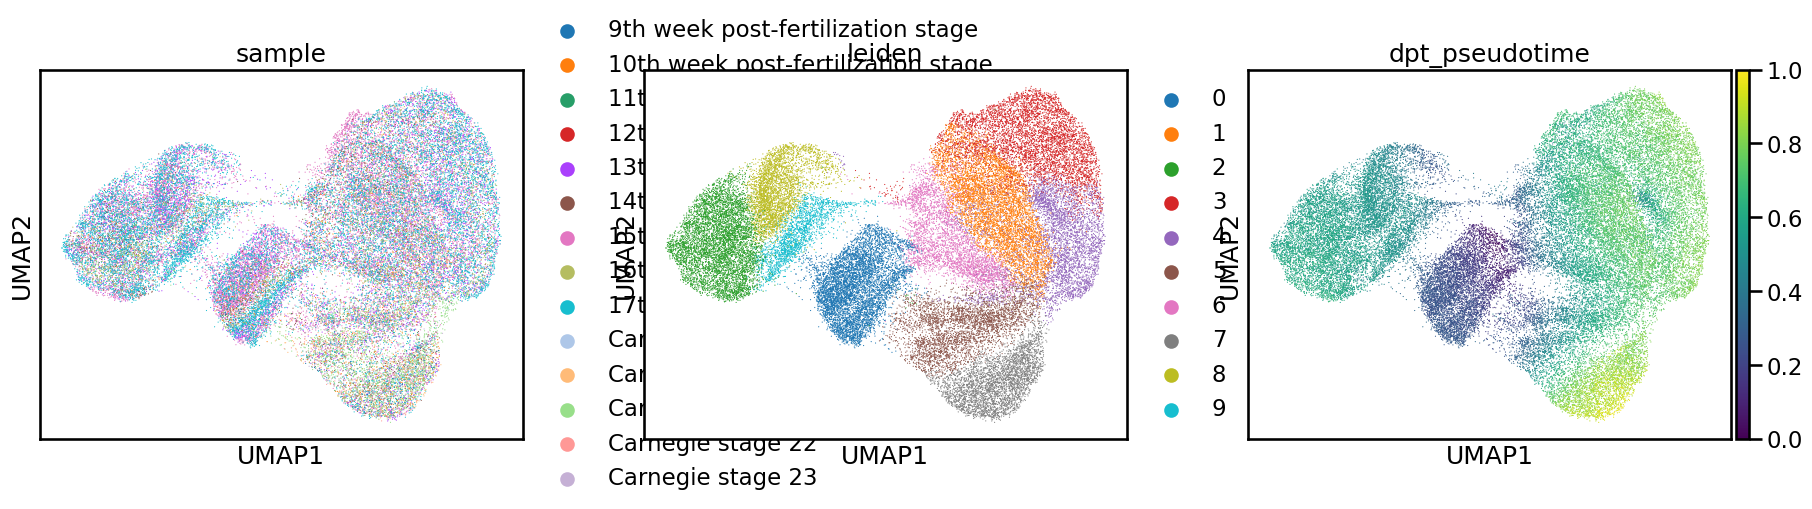

In [7]:
# Prompts: Write codes to use the best method for data integration which can perserve the cell development trajectory across different samples.

import scanpy as sc
import harmonypy as hm
import numpy as np
import bbknn

BATCH_KEY = "sample"

# adata.X is assumed already scaled (as you said)

# PCA on scaled data
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")

# Harmony integrates PCA space (works well for continuous manifolds)
ho = hm.run_harmony(adata.obsm["X_pca"], adata.obs, vars_use=[BATCH_KEY])
adata.obsm["X_pca_harmony"] = ho.Z_corr

# BBKNN builds a batch-balanced KNN graph (often preserves trajectories nicely)
bbknn.bbknn(adata, batch_key=BATCH_KEY, use_rep="X_pca_harmony", neighbors_within_batch=10)

sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.6)

# trajectory
sc.tl.diffmap(adata)
root_cluster = "0"  # change
root_cell = adata.obs_names[adata.obs["leiden"] == root_cluster][0]
adata.uns["iroot"] = int(list(adata.obs_names).index(root_cell))
sc.tl.dpt(adata)

sc.pl.umap(adata, color=["sample", "leiden", "dpt_pseudotime"])


In [8]:
import scanpy as sc
sc

<module 'scanpy' from '/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scanpy/__init__.py'>

In [9]:
# #reference
# sc.pp.neighbors(adata, use_rep='X_pca')
# out11 = check_traj_representation(adata,adata)

In [10]:
out11 = check_traj_representation(adata,adata)

/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scib/metrics/trajectory.py:120: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  n_components, adata_post.obs["neighborhood"] = connected_components(
/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scib/metrics/trajectory.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  start_clust = adata_pre.obs.groupby(ct_key)[pseudotime_key].mean().idxmin()
/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scanpy/tools/_dpt.py:25: ImplicitModificationWarning: Setting element `.obsm['X_diffmap']` of view, initializing view as actual.
  adata.obsm["X_diffmap"] = dpt.eigen_basis
/home/tl688/.conda/envs/agent4bench/lib/python3.9/site-packages/scib/metrics/trajecto

In [11]:
out11

0.9904037442087452

# General evaluation

In [59]:
# test time:
import time
def time_func(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start


In [60]:
# test consistency:
#run code 10 times and compute the mean/variance/average pass rate.

In [61]:
out_list = [out1,out2,out3,out4,out5,out6,out7,out8,out9,out10,out11]

In [62]:
def compute_leaderboard(out_list, method = 'reference'):
    score_list = []
    score_name = []
    for idx,item in enumerate(out_list[0:7]):
        taskid = idx+1
        score_name.append(f'task_{taskid}')
        print(item)
        score_list.append(item.passed*1.0)
        
    #bec
    bec_score = out_list[7]
    
    bec_score_full = bec_score ['Total'].values[0]
    score_name.append('task8_S_total')
    score_list.append(bec_score_full)
    #cluster
    clus_score = out_list[8].metrics
    for i in clus_score.keys():
        score_name.append(f'task9_{i}')
        score_list.append(clus_score[i])
    #deg
    deg_score = out_list[9]
    for i in deg_score.keys():
        if str(deg_score[i])=='nan':
            score_name.append(f'task10_{i}')
            score_list.append(0.0)
        else:
            score_name.append(f'task10_{i}')
            score_list.append(deg_score[i])
            
    #traj
    score_name.append(f'task11')
    score_list.append(out_list[10])
    score_list.append(np.mean(score_list))
    score_name.append('Average')
    df1 = pd.DataFrame(score_list)
    df1.index = score_name
    df1.columns = [method]
    
    return df1

In [63]:
df_out = compute_leaderboard(out_list, method = 'reference')

StepResult(step_id='step1_load_merge', passed=True, checks={'sample_nunique': 11, 'n_obs': 73878, 'n_vars': 19820}, errors=[])
StepResult(step_id='step2_qc_metrics', passed=True, checks={'var_flags_present': True, 'qc_obs_keys_present': True, 'pct_counts_mt_min': 0.0, 'pct_counts_mt_max': 20.68661971830986}, errors=[])
StepResult(step_id='step3_filter', passed=True, checks={'n_obs': 70781, 'n_vars': 19191}, errors=[])
StepResult(step_id='step4_scrublet', passed=False, checks={'scrublet_keys_present': False}, errors=["Missing scrublet keys: ['predicted_doublet', 'doublet_score']"])
StepResult(step_id='step5_normalize_log1p', passed=True, checks={'raw_present': False, 'layers_counts_present': True, 'X_finite': True, 'X_min': 0.09927166302617915}, errors=[])
StepResult(step_id='step6_hvg_pca', passed=True, checks={'hvg_count': 2000, 'X_pca_shape': [70781, 50]}, errors=[])
StepResult(step_id='step7_neighbors_umap', passed=True, checks={'connectivities_shape': [], 'X_umap_shape': [70781, 2]

In [64]:
df_out

,reference
task_1,1.000000
task_2,1.000000
task_3,1.000000
task_4,0.000000
task_5,1.000000
task_6,1.000000
task_7,1.000000
task8_S_total,0.585372
task9_ARI,0.425678
task9_AMI,0.663577


In [65]:
df_out.to_csv(f'./result_folder/gpt52_singlestep_update_{filename}.csv')

In [66]:
import scib

In [67]:
a = 1